# Spain Energy Grid Risk Index — Full Pipeline

**Daily risk forecasting for the Spanish electrical grid (REE) using LightGBM quantile regression.**

This notebook consolidates Phases 1–3 of the project:
1. **Phase 1** — Data Engineering & API Integration (REE + Weather + Calendar + Spot Price)
2. **Phase 2** — Target Creation & Feature Engineering (PCA-based Risk Index)
3. **Phase 3** — Model Training & Evaluation (Asymmetric quantile strategy)

In [1]:
import sys
sys.path.insert(0, '../src')

import json
import warnings
import joblib
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')

# Plotly defaults
plotly_template = "plotly_white"
plotly_font = dict(family="Arial", size=12)
colors = {
    "demand": "#1f77b4",
    "renewables": "#2ca02c",
    "risk_high": "#d62728",
    "risk_medium": "#ff7f0e",
    "risk_low": "#2ca02c",
    "spot": "#ff7f0e",
    "weather": "#9467bd",
    "model": "#1f77b4",
    "baseline": "#7f7f7f",
}
risk_colors = {
    "Low": "#1a9850",  # Deep Green (Safe/Minimal Risk)
    "Stable": "#91cf60",  # Light Green (Normal operation)
    "Elevated": "#ff7f0e",  # Orange (Monitoring required)
    "Severe": "#d62728",  # Red (High stress/Critical)
    "Extreme": "#7f0000",  # Dark Red (Maximum hazard/Emergency)
}


---
# Phase 1: Data Engineering & API Integration

## Data Sources

| Stream | Source | Granularity | Key Variables |
|--------|--------|-------------|---------------|
| Grid Actuals | REE Public API | Hourly → Daily mean | Actual Demand, Generation by tech |
| Day-Ahead Forecast | REE Public API | Hourly → Daily mean | Forecasted Demand |
| Weather | Open-Meteo Archive | Daily | Temp, Wind, Radiation, Precipitation |
| Calendar | `holidays.Spain()` | Daily | Day of Week, Month, Weekend, Holiday |
| Spot Price | REE Public API | Hourly → Daily mean | OMIE Spot Price (EUR/MWh) |
| Derived | Computed from weather | Daily | HDD (Heating Degree Days), CDD (Cooling Degree Days) |

All streams are merged on a common daily date index and saved as `merged_daily_data.parquet`.

### 1.1 Load and Inspect the Merged Dataset

In [2]:
df_raw = pd.read_parquet("../data/merged_daily_data.parquet")
print(f"Shape: {df_raw.shape}")
print(f"Date range: {df_raw.index.min()} to {df_raw.index.max()}")
print("\nColumn types:")
print(df_raw.dtypes.to_string())

Shape: (1898, 20)
Date range: 2020-12-31 to 2026-03-12

Column types:
actual_demand_mw           float64
forecast_demand_mw         float64
gen_wind_mw                float64
gen_solar_pv_mw            float64
gen_hydro_mw               float64
gen_combined_cycle_mw      float64
gen_nuclear_mw             float64
gen_total_mw               float64
spot_price_eur_mwh         float64
temperature_2m_max         float64
temperature_2m_min         float64
wind_speed_10m_max         float64
shortwave_radiation_sum    float64
precipitation_sum          float64
hdd                        float64
cdd                        float64
day_of_week                  int32
month                        int32
is_weekend                   int64
is_holiday                   int64


In [3]:
print("\nMissing values Percentages:")
missing = (df_raw.isna().mean() * 100).round(2)
print(
    missing[missing > 0].to_string() if (missing > 0).any() else "  No missing values"
)


Missing values Percentages:
gen_wind_mw                0.05
gen_solar_pv_mw            0.05
gen_hydro_mw               0.05
gen_combined_cycle_mw      0.05
gen_nuclear_mw             0.05
gen_total_mw               0.05
temperature_2m_max         0.05
temperature_2m_min         0.05
wind_speed_10m_max         0.05
shortwave_radiation_sum    0.05
precipitation_sum          0.05
hdd                        0.05
cdd                        0.05


### 1.2 Feature Distributions

In [4]:
# Demand & Generation distributions
fig = make_subplots(rows=2, cols=3, subplot_titles=[
    "Actual Demand (MW)", "Forecast Demand (MW)", "Spot Price (EUR/MWh)",
    "Wind Generation (MW)", "Solar PV Generation (MW)", "Total Generation (MW)",
])

hist_data = [
    (df_raw["actual_demand_mw"], 1, 1, colors["demand"]),
    (df_raw["forecast_demand_mw"], 1, 2, colors["demand"]),
    (df_raw["spot_price_eur_mwh"], 1, 3, colors["spot"]),
    (df_raw["gen_wind_mw"], 2, 1, colors["renewables"]),
    (df_raw["gen_solar_pv_mw"], 2, 2, colors["renewables"]),
    (df_raw["gen_total_mw"], 2, 3, "#636efa"),
]

for data, row, col, color in hist_data:
    fig.add_trace(go.Histogram(x=data.dropna(), nbinsx=40, marker_color=color,
                               opacity=0.75, showlegend=False), row=row, col=col)

fig.update_layout(height=500, title_text="Grid Data Distributions",
                  template=plotly_template, font=plotly_font)
fig.show()

In [5]:
# Weather feature distributions
fig = make_subplots(rows=2, cols=3, subplot_titles=[
    "Max Temperature (°C)", "Min Temperature (°C)", "Max Wind Speed (km/h)",
    "Shortwave Radiation (MJ/m²)", "Precipitation (mm)", "HDD & CDD",
])

weather_data = [
    (df_raw["temperature_2m_max"], 1, 1, "#d62728"),
    (df_raw["temperature_2m_min"], 1, 2, "#1f77b4"),
    (df_raw["wind_speed_10m_max"], 1, 3, colors["weather"]),
    (df_raw["shortwave_radiation_sum"], 2, 1, "#ff7f0e"),
    (df_raw["precipitation_sum"], 2, 2, "#17becf"),
]

for data, row, col, color in weather_data:
    fig.add_trace(go.Histogram(x=data.dropna(), nbinsx=40, marker_color=color,
                               opacity=0.75, showlegend=False), row=row, col=col)

fig.add_trace(go.Histogram(x=df_raw["hdd"].dropna(), nbinsx=30, marker_color="#1f77b4",
                           opacity=0.6, name="HDD"), row=2, col=3)
fig.add_trace(go.Histogram(x=df_raw["cdd"].dropna(), nbinsx=30, marker_color="#d62728",
                           opacity=0.6, name="CDD"), row=2, col=3)

fig.update_layout(height=500, title_text="Weather Feature Distributions",
                  template=plotly_template, font=plotly_font, barmode="overlay")
fig.show()

---
# Phase 2: Target Creation & Feature Engineering

## Strategy
1. **Chronological split** (BEFORE any fitting): Train ≤ 2023-12-31, Val 2024-01 to 2024-06, Test ≥ 2024-07-01
2. **Core risk factors** (from actuals): `Flexibility_Share`, `Demand_Forecast_Error`, `Net_Load`
3. **PCA** fitted on train only → PC1 → MinMaxScaler → Risk Index [0, 1]
4. **Predictive features** (15): Weather, Calendar, Forecast Demand, Spot Price, Lagged Risk

### 2.1 Chronological Split

In [6]:
train = pd.read_parquet("../data/train.parquet")
val = pd.read_parquet("../data/val.parquet")
test = pd.read_parquet("../data/test.parquet")

print(f"Train: {len(train):,} days  ({train.index.min()} to {train.index.max()})")
print(f"Val:   {len(val):,} days  ({val.index.min()} to {val.index.max()})")
print(f"Test:  {len(test):,} days  ({test.index.min()} to {test.index.max()})")

# Visualize split
split_data = pd.DataFrame({
    "Set": ["Train"] * len(train) + ["Validation"] * len(val) + ["Test"] * len(test),
    "Date": list(train.index) + list(val.index) + list(test.index),
    "Risk Index": list(train["risk_index"]) + list(val["risk_index"]) + list(test["risk_index"]),
})
fig = px.scatter(split_data, x="Date", y="Risk Index", color="Set",
                 color_discrete_map={"Train": "#1f77b4", "Validation": "#ff7f0e", "Test": "#d62728"},
                 opacity=0.5, title="Chronological Train / Validation / Test Split")
fig.update_layout(template=plotly_template, font=plotly_font, height=400)
fig.show()

Train: 1,088 days  (2021-01-08 to 2023-12-31)
Val:   182 days  (2024-01-01 to 2024-06-30)
Test:  620 days  (2024-07-01 to 2026-03-12)


### 2.2 PCA Analysis — Risk Index Construction

In [7]:
fit = joblib.load("../data/artifacts/risk_index_fit.joblib")

ev = fit.pca.explained_variance_ratio_
print(f"Explained variance: PC1={ev[0]:.1%}, PC2={ev[1]:.1%}, PC3={ev[2]:.1%}")
print(f"PC1 weights: {fit.pc1_weights}")
print(f"Thresholds (p33, p67): {fit.thresholds}")

# Explained variance bar chart
fig = go.Figure()
fig.add_trace(go.Bar(
    x=["PC1", "PC2", "PC3"],
    y=ev * 100,
    marker_color=["#1f77b4", "#ff7f0e", "#2ca02c"],
    text=[f"{v:.1f}%" for v in ev * 100],
    textposition="outside",
))
fig.update_layout(
    title="PCA Explained Variance Ratio",
    yaxis_title="Explained Variance (%)",
    template=plotly_template, font=plotly_font, height=400,
)
fig.show()

Explained variance: PC1=61.6%, PC2=33.3%, PC3=5.1%
PC1 weights: [7.07106749e-01 1.47005888e-05 7.07106813e-01]
Thresholds (p33, p67): (0.28292627012349286, 0.40241022300179047, 0.5204520097950651, 0.6526744014660727)


In [8]:
print(train["flexibility_share"].describe())
print("\n")
print(train["demand_forecast_error"].describe())

count    1088.000000
mean        0.347380
std         0.109074
min         0.112059
25%         0.264074
50%         0.340451
75%         0.427211
max         0.672996
Name: flexibility_share, dtype: float64


count    1088.000000
mean       36.923669
std       173.741596
min     -2671.837234
25%        -4.111111
50%        29.041667
75%        72.362847
max      2640.343750
Name: demand_forecast_error, dtype: float64


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


# Check how the factors relate to each other
correlation_matrix = train[
    ["flexibility_share", "demand_forecast_error", "net_load"]
].corr()
print(correlation_matrix)

                       flexibility_share  demand_forecast_error  net_load
flexibility_share               1.000000              -0.004933  0.847408
demand_forecast_error          -0.004933               1.000000  0.001961
net_load                        0.847408               0.001961  1.000000


In [10]:
# PC1 weights visualization
factor_names = ["Flexibility Share", "Demand Forecast Error", "Net Load"]
fig = go.Figure()
fig.add_trace(go.Bar(
    x=factor_names, y=fit.pc1_weights,
    marker_color=["#1f77b4", "#ff7f0e", "#d62728"],
    text=[f"{w:.4f}" for w in fit.pc1_weights],
    textposition="outside",
))
fig.update_layout(
    title="PC1 Component Weights (Risk Index Drivers)",
    yaxis_title="Weight",
    template=plotly_template, font=plotly_font, height=350,
)
fig.show()

### 2.3 Core Operational Stress Factors

In [17]:
from grid_risk import features
df_all = pd.read_parquet("../data/daily_features.parquet")
factors_all = features.compute_core_factors(df_all)
df_all["risk_index"] = features.transform_risk_index(factors_all, fit)
df_all["risk_category"] = features.assign_risk_category(df_all["risk_index"], fit.thresholds)

fig = make_subplots(rows=1, cols=3, subplot_titles=[
    "Flexibility Share", "Demand Forecast Error (MW)", "Net Load (MW)",
])

for i, (col, color) in enumerate([
    ("flexibility_share", "#1f77b4"),
    ("demand_forecast_error", "#ff7f0e"),
    ("net_load", "#d62728"),
], 1):
    fig.add_trace(go.Histogram(x=df_all[col].dropna(), nbinsx=50,
                               marker_color=color, opacity=0.75,
                               showlegend=False), row=1, col=i)

fig.update_layout(height=350, title_text="Distribution of 3 Core Operational Stress Factors",
                  template=plotly_template, font=plotly_font)
fig.show()

### 2.4 Risk Index Time Series by Category

In [18]:
fig = go.Figure()

for cat in ["Low", "Stable", "Elevated", "Severe", "Extreme"]:
    mask = df_all["risk_category"] == cat
    subset = df_all.loc[mask]
    dates = pd.to_datetime(pd.Series(subset.index))
    fig.add_trace(go.Scatter(
        x=dates, y=subset["risk_index"],
        mode="markers", name=cat,
        marker=dict(color=risk_colors[cat], size=3, opacity=0.6),
    ))

p20, p40, p60, p80 = fit.thresholds
fig.add_hline(
    y=p20,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Low/Stable threshold ({p20:.3f})",
)
fig.add_hline(
    y=p40,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Stable/Elevated threshold ({p40:.3f})",
)
fig.add_hline(
    y=p60,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Elevated/Severe threshold ({p60:.3f})",
)
fig.add_hline(
    y=p80,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Severe/Extreme threshold ({p80:.3f})",
)

fig.update_layout(
    title="Daily Risk Index (2021–2026) by Category",
    xaxis_title="Date", yaxis_title="Risk Index [0, 1]",
    template=plotly_template, font=plotly_font, height=450,
)
fig.show()

### 2.5 Feature Correlation Matrix

In [13]:
from grid_risk.features import feature_names

corr = df_all[feature_names + ["risk_index"]].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr.values, x=corr.columns, y=corr.columns,
    colorscale="RdBu_r", zmid=0, text=corr.values.round(2),
    texttemplate="%{text:.2f}", textfont={"size": 8},
))
fig.update_layout(
    title="Feature Correlation Matrix",
    template=plotly_template, font=plotly_font,
    height=600, width=700,
)
fig.show()

---
# Phase 3: Model Training & Evaluation

## Strategy
- **Quantile regression** (α=0.90): The model predicts the 90th percentile of risk, making it systematically pessimistic.
- **Rationale**: A False Negative (missing a blackout) costs **10×** more than a False Positive (false alarm).
- **3 Business Metrics**: RMSE Skill Score (A), Cost Matrix Penalty (B), F₃ Score for High class (C).

### 3.1 Evaluation Results

In [20]:
with open("../data/artifacts/metrics.json") as f:
    metrics = json.load(f)

print("=" * 60)
print("BUSINESS METRICS (Test Set)")
print("=" * 60)
t = metrics["test"]
print(f"  A. RMSE Skill Score:    {t['rmse_skill_score']:.1f}%")
print("     (expected negative for quantile regression — by design)")
print(f"  B. Cost Matrix Penalty: {t['cost_penalty']} pts")
print(f"     Baseline:            {t['baseline_cost_penalty']} pts")
print(f"     Cost Reduction:      {t['cost_reduction_pct']:.1f}%")
print(f"  C. F₃ Score (High):     {t['f3_high']:.3f}")
print()
print("STANDARD METRICS (Test Set)")
print("-" * 40)
print(f"  RMSE: {t['rmse']:.4f}")
print(f"  MAE:  {t['mae']:.4f}")
print(f"  R²:   {t['r2']:.4f}")
print()
print("BASELINES")
print("-" * 40)
b = metrics["baselines"]
print(f"  Persistence RMSE: {b['persistence_test_rmse']:.4f}")
print(f"  Ridge RMSE:       {b['ridge_test_rmse']:.4f}")

BUSINESS METRICS (Test Set)
  A. RMSE Skill Score:    -32.9%
     (expected negative for quantile regression — by design)
  B. Cost Matrix Penalty: 231 pts
     Baseline:            528 pts
     Cost Reduction:      56.2%
  C. F₃ Score (High):     0.831

STANDARD METRICS (Test Set)
----------------------------------------
  RMSE: 0.1791
  MAE:  0.1552
  R²:   -0.1204

BASELINES
----------------------------------------
  Persistence RMSE: 0.1348
  Ridge RMSE:       0.1276


### 3.2 Confusion Matrix

In [15]:
from grid_risk.model import assign_categories
from sklearn.metrics import confusion_matrix

preds = pd.read_parquet("../data/artifacts/test_predictions.parquet")

thresholds = fit.thresholds
y_true_cat = assign_categories(preds["y_true"].values, thresholds)
y_pred_cat = assign_categories(preds["y_pred"].values, thresholds)
y_base_cat = assign_categories(preds["y_baseline"].values, thresholds)

labels = ["Low", "Medium", "High"]

# Model confusion matrix
cm = confusion_matrix(y_true_cat, y_pred_cat, labels=labels)

fig = go.Figure(data=go.Heatmap(
    z=cm, x=labels, y=labels,
    colorscale=[[0, "#f7fbff"], [0.5, "#6baed6"], [1, "#08306b"]],
    text=cm, texttemplate="%{text}",
    textfont={"size": 16},
))
fig.update_layout(
    title="Confusion Matrix — LightGBM Quantile Model (Test Set)",
    xaxis_title="Predicted", yaxis_title="Actual",
    template=plotly_template, font=plotly_font, height=400, width=450,
)
fig.show()

ImportError: cannot import name 'assign_categories' from 'grid_risk.model' (/Users/nicolaswilches/ds/projects/spain-energy-risk-index/notebooks/../src/grid_risk/model.py)

### 3.3 Feature Importance

In [ ]:
feat_imp = pd.read_csv("../data/artifacts/feature_importance.csv")

fig = go.Figure()
fig.add_trace(go.Bar(
    x=feat_imp["importance"],
    y=feat_imp["feature"],
    orientation="h",
    marker_color="#1f77b4",
))
fig.update_layout(
    title="LightGBM Feature Importance (Split-based)",
    xaxis_title="Importance (number of splits)",
    template=plotly_template, font=plotly_font,
    height=450, yaxis=dict(autorange="reversed"),
)
fig.show()

### 3.4 SHAP Analysis

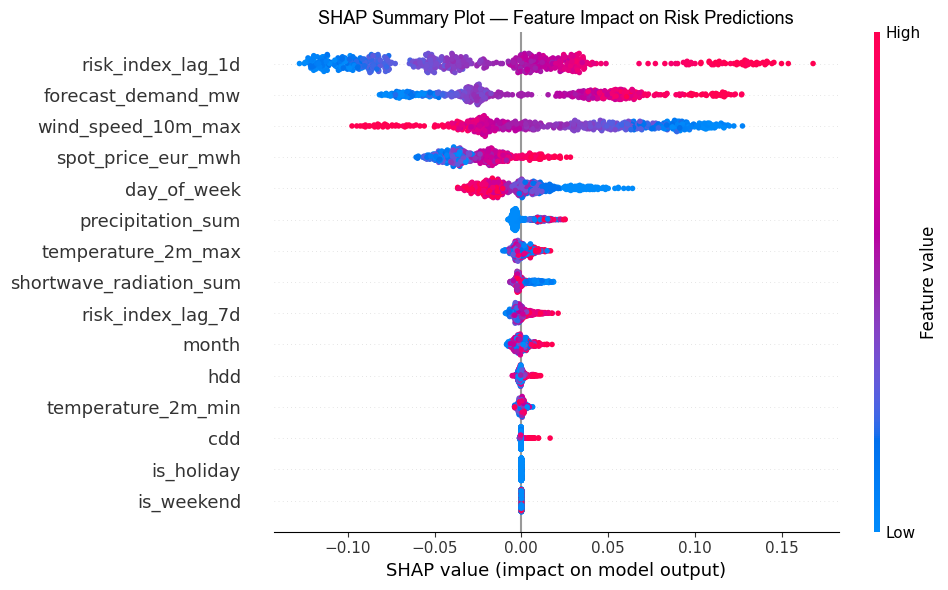

In [ ]:
import shap
import matplotlib.pyplot as plt

model = joblib.load("../data/artifacts/lgbm_model.joblib")
X_test = test[FEATURE_NAMES]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False, plot_size=(10, 6))
plt.title("SHAP Summary Plot — Feature Impact on Risk Predictions", fontsize=13, fontfamily="Arial")
plt.tight_layout()
plt.show()

### 3.5 Actual vs. Predicted Risk Index (Test Set)

In [ ]:
dates = pd.to_datetime(pd.Series(preds["date"]))

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=dates, y=preds["y_true"],
    mode="lines", name="Actual",
    line=dict(color="#2ca02c", width=1),
))
fig.add_trace(go.Scatter(
    x=dates, y=preds["y_pred"],
    mode="lines", name="LightGBM (α=0.90)",
    line=dict(color="#1f77b4", width=1.5),
))
fig.add_trace(go.Scatter(
    x=dates, y=preds["y_baseline"],
    mode="lines", name="Persistence Baseline",
    line=dict(color="#7f7f7f", width=1, dash="dot"),
    opacity=0.5,
))

fig.add_hline(y=fit.thresholds[1], line_dash="dash", line_color="#d62728",
              annotation_text="High Risk Threshold")

fig.update_layout(
    title="Test Set: Actual vs. Predicted Daily Risk Index",
    xaxis_title="Date", yaxis_title="Risk Index [0, 1]",
    template=plotly_template, font=plotly_font, height=450,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

### 3.6 Model vs. Baseline — Classification Comparison

In [ ]:
from grid_risk.model import cost_matrix_penalty, f_beta_high

model_cost = cost_matrix_penalty(y_true_cat, y_pred_cat)
base_cost = cost_matrix_penalty(y_true_cat, y_base_cat)
model_f3 = f_beta_high(y_true_cat, y_pred_cat)
base_f3 = f_beta_high(y_true_cat, y_base_cat)

comparison = pd.DataFrame({
    "Metric": ["Cost Penalty (lower=better)", "F₃ Score (higher=better)"],
    "Persistence Baseline": [base_cost, round(base_f3, 3)],
    "LightGBM Quantile": [model_cost, round(model_f3, 3)],
})
print(comparison.to_string(index=False))

fig = make_subplots(rows=1, cols=2, subplot_titles=[
    "Cost Penalty (Lower = Better)", "F₃ Score — High Class (Higher = Better)",
])

fig.add_trace(go.Bar(
    x=["Persistence", "LightGBM"],
    y=[base_cost, model_cost],
    marker_color=[colors["baseline"],     (df_raw["actual_demand_mw"], 1, 1, colors["demand"]),
["model"]],
    text=[str(base_cost), str(model_cost)],
    textposition="outside",
    showlegend=False,
), row=1, col=1)

fig.add_trace(
    go.Bar(
        x=["Persistence", "LightGBM"],
        y=[base_f3, model_f3],
        marker_color=[
            (df_raw["actual_demand_mw"], 1, 1, colors["demand"]),
            ["baseline"],
            (df_raw["actual_demand_mw"], 1, 1, colors["demand"]),
            ["model"],
        ],
        text=[f"{base_f3:.3f}", f"{model_f3:.3f}"],
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.update_layout(
    title="Model vs. Baseline Comparison",
    template=plotly_template, font=plotly_font, height=380,
)
fig.show()

                     Metric  Persistence Baseline  LightGBM Quantile
Cost Penalty (lower=better)               528.000            231.000
   F₃ Score (higher=better)                 0.586              0.831


---
## Summary

| Metric | Value | Target | Status |
|--------|-------|--------|--------|
| Cost Reduction vs. Baseline | **56.2%** | > 0% | Pass |
| F₃ Score (High class) | **0.831** | > 0.70 | Pass |
| RMSE Skill Score | **-32.9%** | N/A (expected negative) | By design |
| High → Low misclassification | **0** | Minimize | Excellent |

The quantile LightGBM model successfully prioritizes **safety over accuracy**: it catches nearly all High-risk days while accepting some false alarms (Low/Medium predicted as High), which is the desired behavior given the 10:1 FN/FP cost asymmetry.